# BRCA active-inference example

Shared code from `utils.py` and `plotting.py`.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

CWD = Path.cwd().resolve()
REPO_ROOT = CWD.parent if CWD.name in {"BRCA", "CheXpert", "Alphafold", "Stance"} else CWD
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import (
    HUMAN_N_COL,
    EFFECTIVE_N_COL,
    run_odds_ratio_monte_carlo,
    summarize_monte_carlo,
)
from plotting import (
    make_monte_carlo_variance_table,
    plot_coverage,
    plot_effective_sample_size,
    plot_effective_sample_size_multiplier,
    plot_effective_sample_size_and_finite_population_coverage,
    plot_finite_population_coverage,
    plot_intervals,
    plot_monte_carlo_variance,
    plot_monte_carlo_variance_components,
    save_legend,
    save_monte_carlo_variance_table,
    set_theme_bw,
)


## Configuration


In [2]:
EXAMPLE_DIR = REPO_ROOT / "BRCA"
DATA_PATH = REPO_ROOT / "Data" / "BRCA" / "master_df_withpred.csv"
PLOTS_DIR = EXAMPLE_DIR / "plots"
RESULTS_DIR = EXAMPLE_DIR / "results"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 614
ALPHA = 0.10
FRACS_HUMAN = np.linspace(0.2, 0.8, 20)
NUM_TRIALS = 500
TAU = 0.10


## Load data


In [3]:
master_df = pd.read_csv(DATA_PATH)
master_df["strat"] = master_df["race"] + "_" + master_df["is_tnbc"].map({True: "TNBC", False: "nonTNBC"})

train_df, test_df = train_test_split(
    master_df,
    test_size=0.80,
    stratify=master_df["strat"],
    random_state=0,
)

master_df.shape, train_df.shape, test_df.shape


((739, 14), (147, 14), (592, 14))

## Prediction diagnostics


In [4]:
diagnostics = []
for race, group in master_df.groupby("race"):
    diagnostics.append(
        {
            "race": race,
            "n": len(group),
            "tnbc_rate": group["is_tnbc"].mean(),
            "cnn_accuracy": group["is_correct"].mean(),
            "cnn_auc": roc_auc_score(group["is_tnbc"].astype(int), group["predicted_probability"]),
        }
    )

diagnostics.append(
    {
        "race": "overall",
        "n": len(master_df),
        "tnbc_rate": master_df["is_tnbc"].mean(),
        "cnn_accuracy": master_df["is_correct"].mean(),
        "cnn_auc": roc_auc_score(master_df["is_tnbc"].astype(int), master_df["predicted_probability"]),
    }
)

pd.DataFrame(diagnostics)


,race,n,tnbc_rate,cnn_accuracy,cnn_auc
0,B,144,0.284722,0.715278,0.643381
1,W,595,0.142857,0.850420,0.735040
2,overall,739,0.170501,0.824087,0.713625


## Prepare odds-ratio estimand

Group 1 is `W`; group 0 is all non-`W` rows. The estimand is the odds ratio of TNBC prevalence for group 1 versus group 0.


In [5]:
yhat = master_df["predicted_probability"].to_numpy(dtype=float)
y = master_df["is_tnbc"].to_numpy(dtype=float)
group1 = master_df["race"].to_numpy() == "W"

yhat1, yhat0 = yhat[group1], yhat[~group1]
y1, y0 = y[group1], y[~group1]
n0, n1 = len(y0), len(y1)
n = n0 + n1

mu0 = y0.mean()
mu1 = y1.mean()
true_odds_ratio = (mu1 / (1 - mu1)) / (mu0 / (1 - mu0))
true_variance = (
    1 / np.sum(y0 == 0)
    + 1 / np.sum(y0 == 1)
    + 1 / np.sum(y1 == 0)
    + 1 / np.sum(y1 == 1)
) * n

mu0_train = train_df.loc[train_df["race"] != "W", "is_tnbc"].mean()
mu1_train = train_df.loc[train_df["race"] == "W", "is_tnbc"].mean()

{
    "n_group0": n0,
    "n_group1": n1,
    "mu0": mu0,
    "mu1": mu1,
    "true_odds_ratio": true_odds_ratio,
    "true_variance": true_variance,
    "mu0_train": mu0_train,
    "mu1_train": mu1_train,
}


{'n_group0': 144,
 'n_group1': 595,
 'mu0': 0.2847222222222222,
 'mu1': 0.14285714285714285,
 'true_odds_ratio': 0.4186991869918699,
 'true_variance': 35.3422847803578,
 'mu0_train': 0.27586206896551724,
 'mu1_train': 0.1440677966101695}

## Monte Carlo comparison

The result table records the point estimate, log point estimate, analytic variance estimate, interval endpoints, interval width, coverage, effective sample size, empirical Monte Carlo variance by method and budget, and the finite-population-calibrated interval used to evaluate coverage against the fixed empirical population.


In [6]:
df = run_odds_ratio_monte_carlo(
    y0=y0,
    yhat0=yhat0,
    y1=y1,
    yhat1=yhat1,
    fracs_human=FRACS_HUMAN,
    alpha=ALPHA,
    num_trials=NUM_TRIALS,
    true_odds_ratio=true_odds_ratio,
    true_variance=true_variance,
    mu0_pilot=mu0_train,
    mu1_pilot=mu1_train,
    tau=TAU,
    seed=SEED,
    split_spline_budget_evenly=False,
    show_progress=True,
)

summary_df = summarize_monte_carlo(df)
mc_variance_table = make_monte_carlo_variance_table(df)

df.to_csv(RESULTS_DIR / "BRCA_results.csv", index=False)
summary_df.to_csv(RESULTS_DIR / "BRCA_monte_carlo_summary.csv", index=False)
mc_variance_table.to_csv(RESULTS_DIR / "BRCA_monte_carlo_variance_components.csv", index=False)

mc_variance_table.head(12)


human budget:   0%|          | 0/20 [00:00<?, ?it/s]

trials 0.200:   0%|          | 0/500 [00:00<?, ?it/s]

trials 0.232:   0%|          | 0/500 [00:00<?, ?it/s]

trials 0.263:   0%|          | 0/500 [00:00<?, ?it/s]

trials 0.295:   0%|          | 0/500 [00:00<?, ?it/s]

...

trials 0.705:   0%|          | 0/500 [00:00<?, ?it/s]

trials 0.737:   0%|          | 0/500 [00:00<?, ?it/s]

trials 0.768:   0%|          | 0/500 [00:00<?, ?it/s]

trials 0.800:   0%|          | 0/500 [00:00<?, ?it/s]

,$n_{\mathrm{human}}$,estimator,point_estimate_mean,point_estimate_variance,lb_mean,lb_variance,ub_mean,ub_variance,interval_width_mean,interval_width_variance,coverage,finite_population_coverage,finite_population_interval_width,finite_population_variance_inflation
0,147,active,0.466762,0.059055,0.196371,0.007306,1.139558,0.711371,0.943187,0.612410,0.958,0.918,0.827097,1.238434
1,147,active + tuning,0.490810,0.098874,0.213912,0.011474,1.142316,1.039412,0.928404,0.860072,0.930,0.898,0.800727,1.271633
2,147,classical,0.473906,0.056149,0.202108,0.007645,1.123591,0.464539,0.921483,0.364895,0.938,0.896,0.782464,1.331777
3,147,spline,0.442072,0.025800,0.216606,0.007703,0.911516,0.092993,0.694910,0.053131,0.960,0.922,0.585212,1.340742
4,147,spline + tuning,0.441878,0.024442,0.223784,0.006635,0.874570,0.093731,0.650786,0.052400,0.948,0.904,0.536609,1.400035
5,147,uniform,0.474480,0.065079,0.199230,0.007470,1.178167,1.484731,0.978938,1.381270,0.948,0.922,0.860764,1.235786
6,171,active,0.463714,0.040164,0.210729,0.006834,1.037056,0.317135,0.826327,0.250669,0.966,0.922,0.710671,1.290659
7,171,active + tuning,0.473963,0.041048,0.223382,0.007942,1.010700,0.225986,0.787317,0.154099,0.946,0.900,0.666899,1.328418
8,171,classical,0.478190,0.054691,0.217279,0.008092,1.062367,0.420070,0.845088,0.323117,0.940,0.902,0.710996,1.355354
9,171,spline,0.433016,0.022986,0.222728,0.007802,0.847959,0.068346,0.625231,0.032905,0.964,0.896,0.512160,1.414710


## Plots


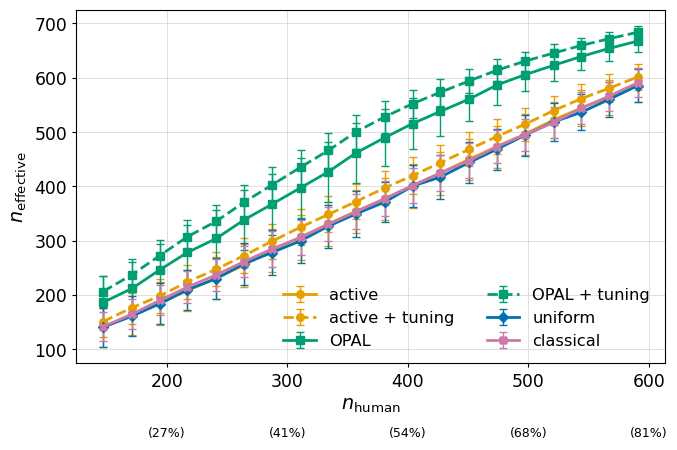

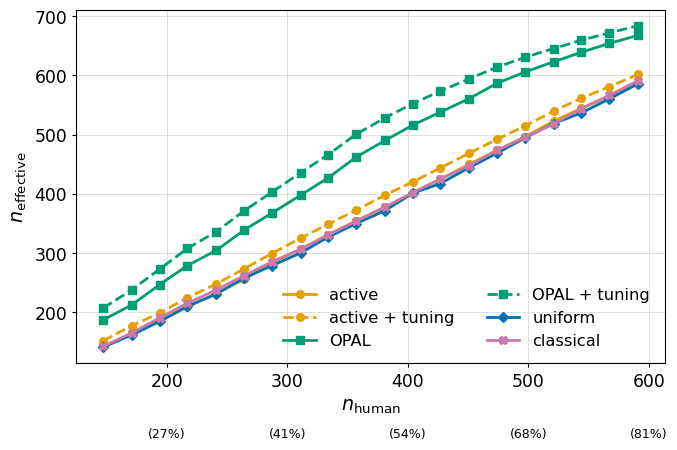

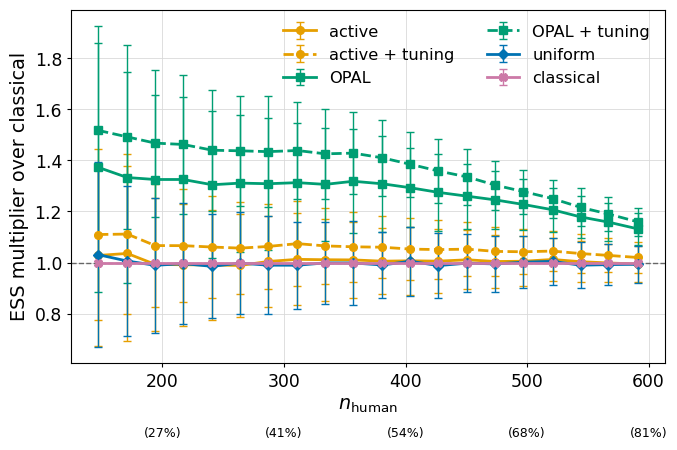

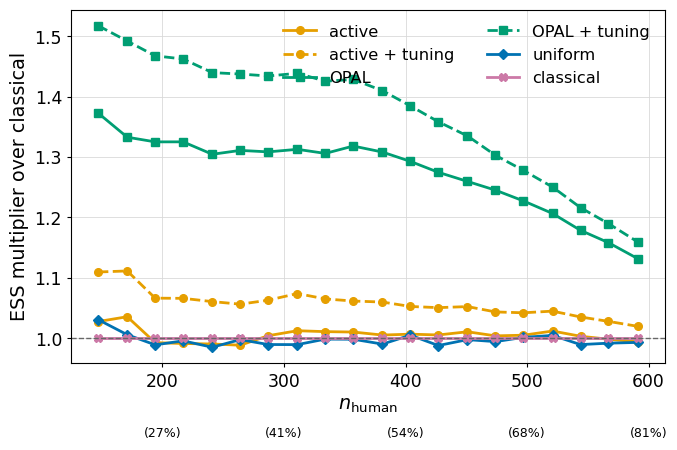

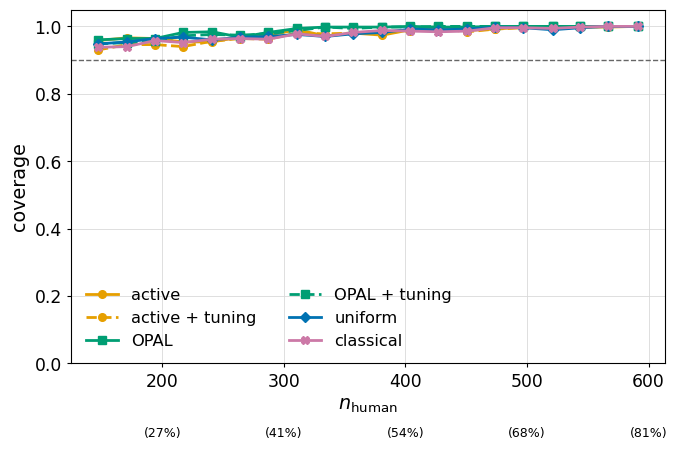

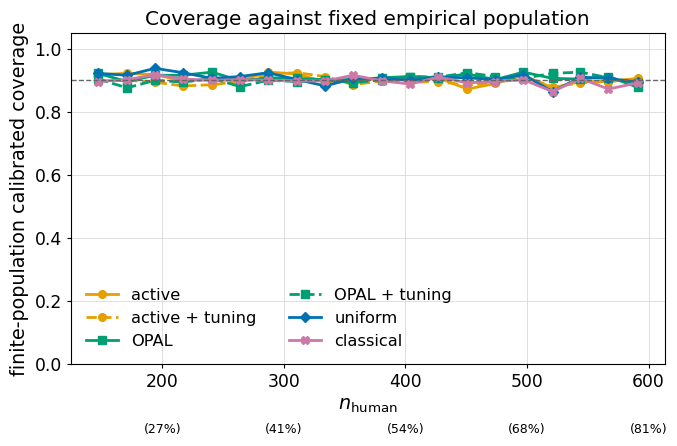

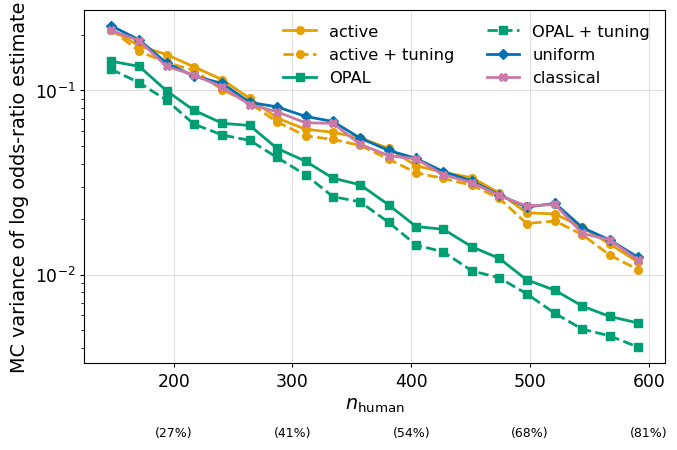

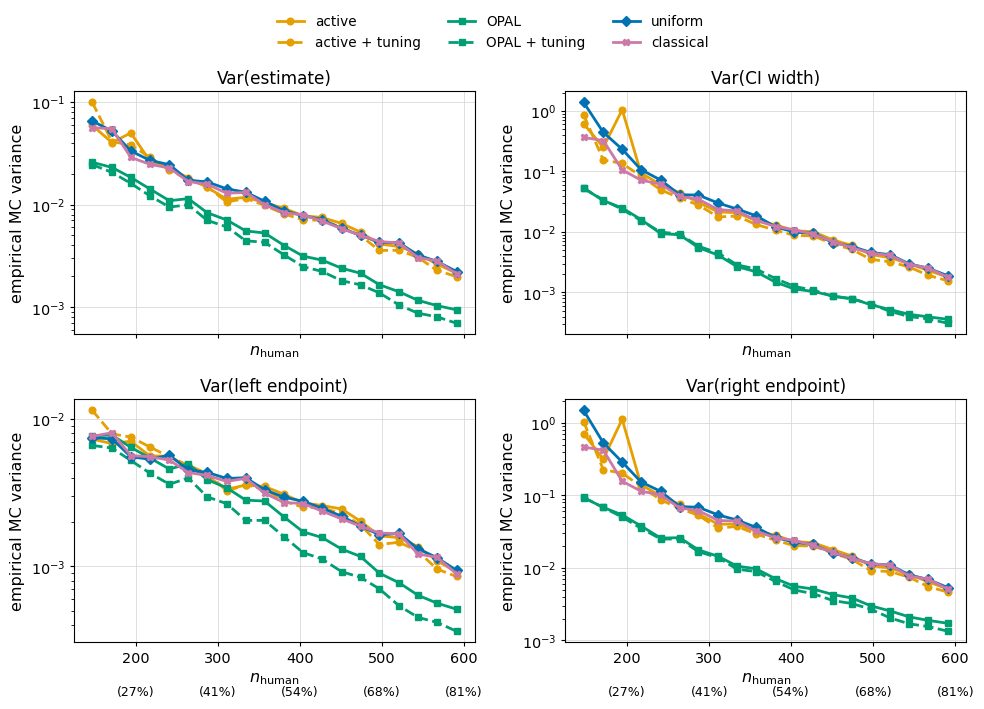

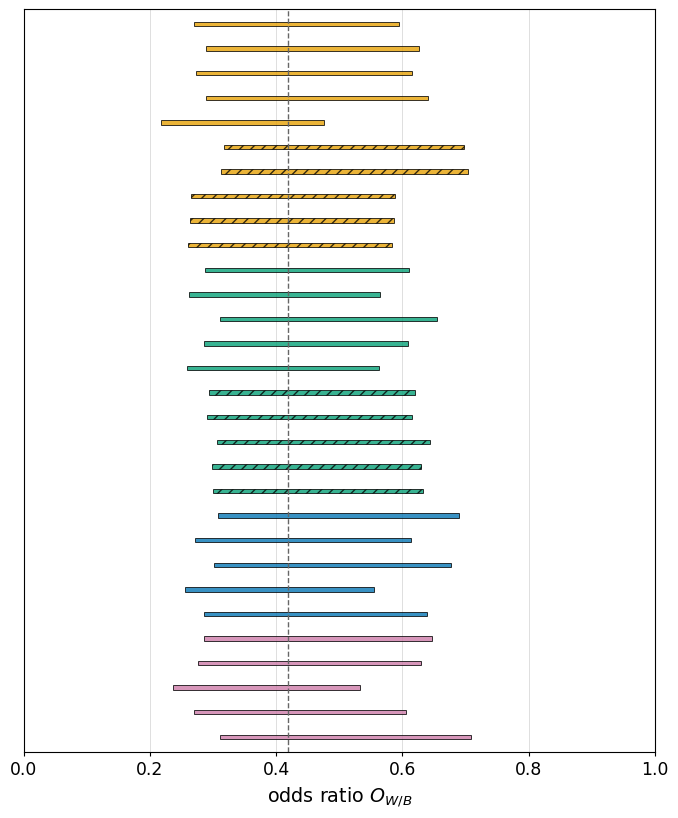

(<Figure size 850x140 with 1 Axes>, <Axes: >)

In [7]:
set_theme_bw()
plot_effective_sample_size(
    df,
    path=PLOTS_DIR / "BRCA_effective_sample_size.pdf",
    n_total=n,
    error_bars="sd",
)
plot_effective_sample_size(
    df,
    path=PLOTS_DIR / "BRCA_effective_sample_size_no_error_bars.pdf",
    n_total=n,
    error_bars="none",
)
plot_effective_sample_size_multiplier(
    df,
    path=PLOTS_DIR / "BRCA_effective_sample_size_multiplier.pdf",
    n_total=n,
    error_bars="sd",
)
plot_effective_sample_size_multiplier(
    df,
    path=PLOTS_DIR / "BRCA_effective_sample_size_multiplier_no_error_bars.pdf",
    n_total=n,
    error_bars="none",
)
plot_effective_sample_size_and_finite_population_coverage(
    df,
    alpha=ALPHA,
    path=PLOTS_DIR / "BRCA_effective_sample_size_and_corrected_coverage.pdf",
    n_total=n,
)
plot_effective_sample_size_and_finite_population_coverage(
    df,
    alpha=ALPHA,
    path=PLOTS_DIR / "BRCA_effective_sample_size_and_corrected_coverage.png",
    n_total=n,
    show=False,
)
plot_coverage(
    df,
    alpha=ALPHA,
    path=PLOTS_DIR / "BRCA_coverage.pdf",
    n_total=n,
)
plot_finite_population_coverage(
    df,
    alpha=ALPHA,
    path=PLOTS_DIR / "BRCA_coverage_finite_population_calibrated.pdf",
    n_total=n,
)
plot_monte_carlo_variance(
    df,
    path=PLOTS_DIR / "BRCA_mc_log_variance.pdf",
    use_log=True,
    n_total=n,
)
plot_monte_carlo_variance_components(
    df,
    path=PLOTS_DIR / "BRCA_mc_variance_components.pdf",
    n_total=n,
)
save_monte_carlo_variance_table(
    df,
    path=PLOTS_DIR / "BRCA_mc_variance_components_table.pdf",
)
plot_intervals(
    df,
    true_value=true_odds_ratio,
    path=PLOTS_DIR / "BRCA_intervals.pdf",
    estimand_label=r"odds ratio $O_{W/B}$",
    n_index=-1,
    num_intervals=5,
    seed=SEED,
)
save_legend(PLOTS_DIR / "BRCA_legend.pdf")


## Stability summary


In [8]:
mc_variance_table


,$n_{\mathrm{human}}$,estimator,point_estimate_mean,point_estimate_variance,lb_mean,lb_variance,ub_mean,ub_variance,interval_width_mean,interval_width_variance,coverage,finite_population_coverage,finite_population_interval_width,finite_population_variance_inflation
0,147,active,0.466762,0.059055,0.196371,0.007306,1.139558,0.711371,0.943187,0.612410,0.958,0.918,0.827097,1.238434
1,147,active + tuning,0.490810,0.098874,0.213912,0.011474,1.142316,1.039412,0.928404,0.860072,0.930,0.898,0.800727,1.271633
2,147,classical,0.473906,0.056149,0.202108,0.007645,1.123591,0.464539,0.921483,0.364895,0.938,0.896,0.782464,1.331777
3,147,spline,0.442072,0.025800,0.216606,0.007703,0.911516,0.092993,0.694910,0.053131,0.960,0.922,0.585212,1.340742
4,147,spline + tuning,0.441878,0.024442,0.223784,0.006635,0.874570,0.093731,0.650786,0.052400,0.948,0.904,0.536609,1.400035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,591,active + tuning,0.423326,0.001983,0.283999,0.000854,0.631047,0.004650,0.347048,0.001560,1.000,0.904,0.144796,5.504451
116,591,classical,0.418272,0.002119,0.279565,0.000890,0.625852,0.005098,0.346287,0.001779,1.000,0.892,0.151646,5.003561
117,591,spline,0.418052,0.000944,0.286414,0.000512,0.610213,0.001725,0.323799,0.000360,1.000,0.878,0.097228,10.625418
118,591,spline + tuning,0.418556,0.000698,0.288024,0.000363,0.608252,0.001341,0.320228,0.000310,1.000,0.892,0.084860,13.632863
